# Root finding

## Introduction

As an introduction, let's watch the video below:

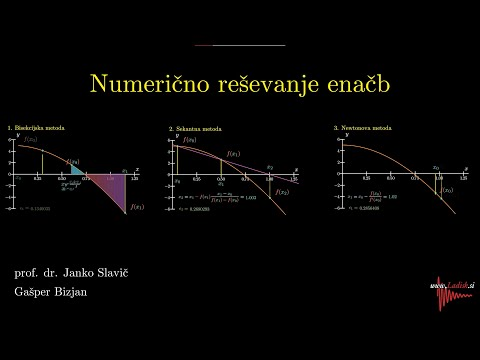

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('17d55KE8SIU', width=800, height=300)

In root finding we consider an arbitrary equation that depends on the variable $x$ and we look for the solution:

$$f(x)=0.$$

The solutions of the equation are also called *roots*. A root of the equation $f(x)=0$ is at the same time a zero of the function $y=f(x)$.

The function $y=f(x)$ can have zeros of order:

* first-order zero: the function crosses the horizontal axis at a nonzero angle,
* even-order zeros: the function touches the horizontal axis but does not cross it,
* odd-order zeros: the function crosses the horizontal axis; for a zero of order 3 or higher there is an inflection point (the tangent is parallel to the horizontal axis).

It is important to point out here that we are looking for the solution of an arbitrary equation $f(x)=0$. While for linear, quadratic, or cubic equations we can determine analytical solutions, for most nonlinear equations an analytical solution cannot be found. For this reason numerical approaches are all the more important.

### Restrictions on the function $f(x)$

We require that the function $y=f(x)$ be continuous on the closed interval $[x_0, x_1]$. When computing zeros, we will restrict ourselves only to first-order zeros.

### Example

An arbitrary function $y=f(x)$ can be defined with a *Python function*; as an example, let's define a polynomial here:

In [2]:
def f(x):
    return x**3 - 10*x**2 + 5

Since this is the polynomial $x^3-10x^2+5$ with coefficients `[1, -10, 0, 5]`, it is better to define it using [`np.poly1d`](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html):

```python
numpy.poly1d(c_or_r, r=False, variable=None)
```

where the parameters are:

* `c_or_r` the coefficients of the polynomial in order of decreasing power, or, if `r=True`, the roots of the polynomial,
* `r` is `False` by default, which means that the polynomial coefficients are given,
* `variable` the variable that is printed when using the `print()` function.

**Note**: `np.poly1d` belongs to the older interface; the more modern one is the class `numpy.polynomial.Polynomial` ([documentation](https://numpy.org/doc/stable/reference/routines.polynomials.html)), which expects the coefficients in **increasing** order of powers: `Polynomial([5, 0, -10, 1])`. The object is likewise called as a function, and the zeros are obtained with the method `roots()`.

Let's import `numpy` and define the polynomial:

In [3]:
import numpy as np # import numpy
f = np.poly1d([1, -10, 0, 5]) # define the polynomial coefficients
print(f) # display the polynomial

   3      2
1 x - 10 x + 5


Let's plot the function $f(x)$:

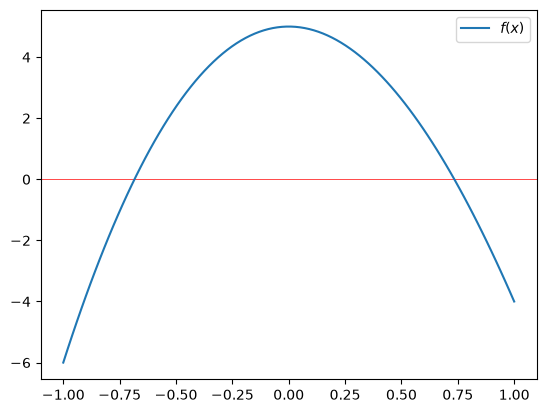

In [4]:
import matplotlib.pyplot as plt       # import matplotlib
%matplotlib inline
x_r = np.linspace(-1, 1, 100)
plt.axhline(0, color='r', lw=0.5)     # horizontal line,
plt.plot(x_r, f(x_r), label='$f(x)$') # so that a zero is somewhere near $x = 0.7$.
plt.legend();

We notice that the zeros of the function $f(x)$ are near -0.7 and +0.7. The `poly1d` object has an attribute `roots`, or also `r` ([see the documentation](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html)), which returns these zeros:

In [5]:
f.r

array([ 9.94949106,  0.73460351, -0.68409457])

In what follows, our goal will be to numerically determine a zero for an arbitrary function `f`.

## Incremental method

Incremental solving is based on the idea that if the function $f(x)$ has different signs at $x_0$ and $x_1$, then there is at least one zero in between. We therefore divide the closed interval $[x_0, x_1]$ into segments of width $\Delta x$; on the segment where we observe a sign change, there is at least one zero of the function.

The method is shown in the figure.
![Incremental method](./fig/inkrementalna.png)

For a zero we require:

$$\left|x_{i+1}-x_i\right|<\varepsilon\quad\textrm{in}\quad \left|f(x_{i+1})\right|+\left|f(x_{i})\right|<D,$$

where $\varepsilon$ is the required accuracy of the solution and $D$ is a chosen small value that prevents us from identifying a pole as a zero (which is otherwise not possible because of the continuity condition).

The incremental method has some drawbacks:

* it is very slow,
* it can miss two zeros that are very close to each other,
* it does not detect multiple even-order zeros (a local extremum that only touches the horizontal axis).

The incremental method belongs to the so-called *bracketed* methods, since it looks for zeros of the function only on the interval $[x_0, x_1]$. Later we will also learn about *open* methods, which can converge to a zero outside the given interval.

Because of all the drawbacks listed above, the incremental method is often used only to compute an initial estimate of a zero.

### Numerical implementation

Let's now look at the incremental search for zeros of a function:

In [6]:
def incremental(fun, x0, x1, dx):
    """ Returns the first interval (x1, x2) where a zero lies

    :param fun: function whose zeros we are looking for
    :param x1:  lower search bound
    :param x2:  upper search bound
    :param dx:  search increment
    """
    x_d = np.arange(x0, x1, dx)   # prepare the x values
    f_d = np.sign(fun(x_d))       # prepare the signs of the function
    f_d = f_d[1:]*f_d[:-1]        # multiply neighboring elements
    i = np.argmin(f_d)            # first crossing through zero
    # sum of abs function values
    x0 = x_d[i]
    x1 = x_d[i+1]
    D = np.abs(fun(x0)) + np.abs(fun(x1))
    return np.asarray([x0, x1]), D

Let's now look at the usage on the polynomial defined above:

In [7]:
incr_result, D = incremental(f, 0., 1., 0.001)
incr_result

array([0.734, 0.735])

The zero is isolated with an accuracy of 0.001; let's also check the sum of the absolute function values:

In [8]:
D

np.float64(0.013071529000000304)

We find that it is relatively small; with the following methods we will, however, try to substantially improve the result.

Let's prepare the figure:

In [9]:
def fig():
    plt.plot(x_r, f(x_r), label='$f(x)$')
    plt.axhline(0, color='r', lw=0.5)     # horizontal line
    plt.axvline(incr_result[0], color='r', lw=0.5)     # vertical line
    plt.axvline(incr_result[1], color='r', lw=0.5)     # vertical line
    plt.plot(incr_result, f(incr_result), 'ro', label='Incremental method')
    plt.xlim(0.73,0.74)
    plt.ylim(-0.1, 0.1)
    plt.legend();

Let's display the result:

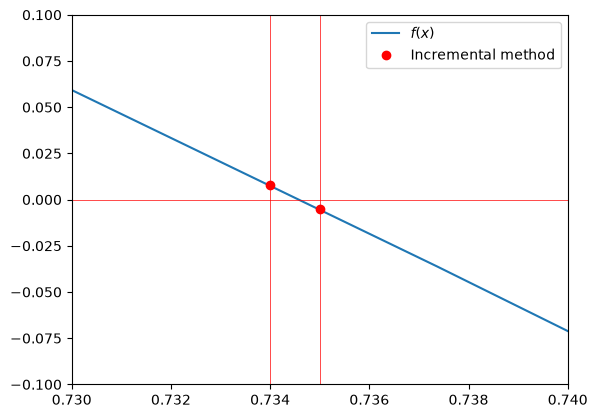

In [10]:
fig()

So in order to compute the solution on the interval $[0, 1]$ with an accuracy of $\Delta x=0.001$, we had to call the function $f(x)$ 1000 times. This is a very inefficient method, so we will look for better approaches; first with a simple iterative incremental approach.

## Iterative incremental method

In the first iteration, the iterative incremental method uses the incremental method to bracket the search interval for zeros at a relatively large step. The interval found in the first iteration is divided into smaller intervals in the second iteration, and the incremental search for the zero is repeated. The third iteration then restricts itself to the interval determined in the second, and so on. We stop iterating once we have reached the prescribed accuracy of the solution $\epsilon$.

The method is shown in the figure:
![Iterative incremental method](./fig/iterativna_inkrementalna.png)

### Numerical implementation

In [11]:
def incremental_super(fun, x0, x1, iterations=3):
    """ Returns the interval (x0, x1) where a zero lies

    :param fun: function whose zero we are looking for
    :param x0:  lower search bound
    :param x1:  upper search bound
    :iterations: number of iterations of the incremental method
    """
    for i in range(iterations):
        dx = (x1 - x0)/10
        x0x1, _ = incremental(fun, x0, x1, dx)
        x0, x1 = x0x1
    # sum of abs function values
    D = np.abs(fun(x0)) + np.abs(fun(x1))
    return np.asarray([x0, x1]), D

With 30 calls to the function $f(x)$ we thus obtain accuracy similar to the previous 1000:

In [12]:
result30, D30 = incremental_super(f, 0., 1., iterations=3)
result30

array([0.734, 0.735])

In [13]:
incr_result

array([0.734, 0.735])

Of course, we can substantially improve the accuracy by increasing the number of iterations:

In [14]:
result80, D80 = incremental_super(f, 0., 1., iterations=8)
result80

array([0.7346035 , 0.73460351])

Let's also check the criterion of the sum of the absolute function values, which must be small:

In [15]:
D80

np.float64(1.3073143190212022e-07)

## Bisection method

On the interval $[x_0, x_1]$, where we know that a zero of the function exists (the signs of $f(x_0)$ and $f(x_1)$ differ), we can use the *bisection method*.

The idea of the method is:

* divide the interval $[x_0, x_1]$ in half (hence the name: *bi-section*): $x_2 = (x_0+x_1)/2$,
* if $f(x_0)$ and $f(x_2)$ have different signs, the new search interval for the zero is $[x_0, x_2]$, otherwise: $[x_2, x_1]$,
* based on the previous step, we define a new closed interval $[x_0, x_1]$ and continue the iterative procedure until we reach the desired accuracy $\left|x_1-x_0\right|<\varepsilon$.

Figure of the method:
![Bisection method](./fig/bisekcijska.png)

The bisection method belongs to the *bracketed* methods, which return a zero of the function on the given interval $[x_0, x_1]$.

### Error estimate

If we start with the interval $\Delta x = \left|x_1-x_0\right|$, then the accuracy of the bisection method after the first bisection step is:

$$\varepsilon_1 = \Delta x/2,$$

after the second step:

$$\varepsilon_2 = \Delta x/2^2$$

and after $n$ steps:

$$\varepsilon_n = \Delta x/2^n.$$

Usually we require that the solution be given with an accuracy $\varepsilon$, and from the equation above we can derive the number of bisection steps required:

$$n = \frac{\log\left(\frac{\Delta x}{\varepsilon}\right)}{\log(2)}.$$

Of course, the number of steps is an integer.

### Numerical implementation

In [16]:
def bisection(fun, x0, x1, tol=1e-3, Dtol=1e-1, verbose=True):
    """ Returns a zero with accuracy tol

    :param fun: function whose zero we are looking for
    :param x0:  lower search bound
    :param x1:  upper search bound
    :param tol: required accuracy
    :param Dtol:maximum sum of absolute values of the solution
    :verbose:   whether to print a short report at the end
    """
    if np.sign(fun(x0))==np.sign(fun(x1)):
        raise Exception('Root is not bracketed.')
    n = np.ceil( np.log(np.abs(x1-x0)/tol)/np.log(2) ).astype(int) # number of iterations
    for i in range(n):
        x2 = (x0 + x1) / 2
        f1 = fun(x0)
        f3 = fun(x2)
        f2 = fun(x1)
        if np.sign(fun(x2))!=np.sign(fun(x0)):
            x1 = x2
        else:
            x0 = x2
    D = np.abs(fun(x0)) + np.abs(fun(x1))
    if D > Dtol:
        raise Exception('Likely a pole or multiple zeros.')
    r = (x0+x1)/2
    if verbose:
        decimals = int(np.log10(1/tol)) # does not always work for all cases:)
        print(f'Solution: {r:5.{decimals}f}, number of iterations: {n:g}, D: {D:5.5f}')
    return r

Now let's try to find the zero with an accuracy of `1e-3`:

In [17]:
bisection(f, 0, 1, tol=1e-3);

Solution: 0.735, number of iterations: 10, D: 0.01277


In ten iterations we obtained the same accurate result as above with the iterative incremental method `result30`. Let's also look at computing the zero with even greater accuracy:

In [18]:
bisection(f, 0, 1, tol=1e-6);

Solution: 0.734603, number of iterations: 20, D: 0.00001


We can check the execution speed with the so-called *magic function* ``timeit`` ([documentation](http://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit)), which runs the function several times and analyzes the execution time. If the magic function is preceded by the double symbol `%%`, it executes and times the entire cell, but if only a single `%`, then only one line.

In [19]:
%%timeit
bisection(f, 0., 1., verbose=False)

348 μs ± 4.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


#### Searching for a zero near a pole
Let's now look at searching for a zero of the ``tan`` function near a pole (the zero does not actually exist):

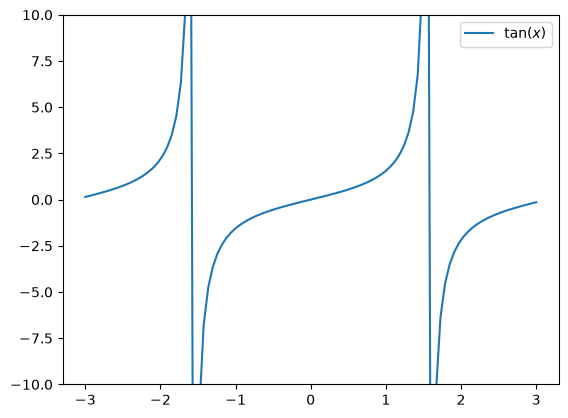

In [20]:
x_t = np.linspace(-3, 3, 100)
plt.plot(x_t, np.tan(x_t), label='$\\tan(x)$')
plt.ylim(-10, 10)
plt.legend();

In the case of searching on the interval $[-1, 1]$ we find the correct zero:

In [21]:
bisection(np.tan, -1, 1, tol=1e-3);

Solution: -0.000, number of iterations: 11, D: 0.00098


In the case of searching near a pole, however, the program warns us about it (the function call is commented out here, otherwise the automatic generation is interrupted here):

In [22]:
## bisection(np.tan, -3, 0, tol=1e-6)

The bisection method built into ``scipy`` does not have such a check (for the sake of speed) and will return a result, which will, however, be wrong. So we must be careful when using it.

### Using ``scipy.optimize.root_scalar``

The bisection method is a *slow* but reliable method for finding zeros and is implemented within ``scipy``. First we import it:

In [23]:
from scipy.optimize import root_scalar

```python
root_scalar(f, args=(), method='bisect', bracket=[a,b], fprime=None, fprime2=None, x0=None, x1=None,xtol=None, rtol=None, maxiter=None, options=None)
```

To invoke the bisection method with the `root_scalar` function, we must pass three parameters to the function: the function `f` and the closed interval `[a, b]` (via the `bracket` parameter). The signs of `f(a)` and `f(b)` must be different. The other parameters, e.g. the absolute `xtol` and relative `rtol` error, and the maximum number of iterations `maxiter`, are optional - they have default values. For more, see the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html).

Let's look at the usage:

In [24]:
root_scalar(f, bracket=[0, 1], method='bisect')

      converged: True
           flag: converged
 function_calls: 41
     iterations: 39
           root: 0.7346035077880515
         method: bisect

and the speed:

In [25]:
%timeit root_scalar(f, bracket=[0, 1], method='bisect')

324 μs ± 2.83 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


We can also check the function `tan(x)`, first on an interval where the function is continuous:

In [26]:
root_scalar(np.tan, bracket=[-1, 1], method='bisect')

      converged: True
           flag: converged
 function_calls: 3
     iterations: 1
           root: 0.0
         method: bisect

Then also near a pole, where it is not continuous:

In [27]:
root_scalar(np.tan, bracket=[-3, -1], method='bisect')

      converged: True
           flag: converged
 function_calls: 42
     iterations: 40
           root: -1.5707963267941523
         method: bisect

which is a wrong solution!

## Secant method

The secant method requires two initial estimates $x_0$ and $x_1$ and a function $f(x)$. Assuming linear interpolation between the points $x_0, f(x_0)$ and $x_1, f(x_1)$ (we draw a *secant* through the points, hence the name), $x_2$ is determined, where the linear interpolating function has a zero. $x_2$ represents the new estimate of the zero.


Based on the figure:
![Secant method](./fig/sekantna.png)

we can write (similar triangles are marked in yellow in the figure):

$$\frac{f(x_1)}{x_2 − x_1}= \frac{f(x_0) − f(x_1)}{x_1 − x_0}.$$

It follows that the new estimate of the zero is:

$$x_2= x_1-f(x_1)\,\frac{x_1 − x_0}{f(x_1) - f(x_0)}.$$

In the next step of the secant method we perform the following substitutions: $x_0=x_1$ and $x_1=x_2$.

The secant method belongs to the *open* methods, since it can find a zero of the function that lies outside the domain $[x_0, x_1]$.

### Error estimate

Conservatively, we can estimate the error from the difference between two consecutive estimates:

$$\varepsilon = \left|x_{n-1} -x_{n}\right|$$

### Convergence and order of convergence

Convergence means that the sequence of estimates converges to the solution of the equation $\alpha$ ($\alpha$ is the solution of the equation).

**The order of convergence** indicates the speed of convergence.

If we denote by $\varepsilon$ the error of the estimate and reduce the error linearly with each iteration step ($C$ is a constant):

$$\varepsilon_n = C\,\varepsilon_{n-1}^1,$$

we speak of **order of convergence 1** ($\varepsilon$ has the power 1)!

In the previously discussed bisection method, we halve the error at each step ($\varepsilon_n/\varepsilon_{n-1} = C = 1/2$). *The bisection method has order of convergence 1.*

The order of convergence *of the secant method is higher* and can be estimated as:

$$\varepsilon_n = C\,\varepsilon_{n-1}^{1.618}.$$

From the estimate above it follows that at each iteration step the number of correct digits increases by about 60%. Since the order of convergence is higher than 1 and lower than quadratic, such convergence is called *superlinear* convergence.

### Numerical implementation

In [28]:
def secant(fun, x0, x1, tol=1e-3, Dtol=1e-1, max_iter=50, verbose=True):
    """ Returns a zero with accuracy tol

    :param fun: function whose zero we are looking for
    :param x0:  lower search bound
    :param x1:  upper search bound
    :param tol: required accuracy
    :max_iter:  maximum number of iterations before execution is interrupted
    :param Dtol:maximum sum of absolute values of the solution
    :verbose:   whether to print a short report at the end
    """
    if np.sign(fun(x0))==np.sign(fun(x1)):
        raise Exception('Root is not bracketed.')
    for i in range(max_iter):
        f0 = fun(x0)
        f1 = fun(x1)
        x2 = x1 - f1 * (x1 - x0)/(f1 - f0)
        x0 = x1
        x1 = x2
        if verbose:
            print('{:g}. step: x0={:g}, x1={:g}.'.format(i+1, x0, x1))
        if np.abs(x1-x0)<tol:
            r = (x0+x1)/2
            D = np.abs(fun(x0)) + np.abs(fun(x1))
            if D > Dtol:
                raise Exception('Likely a pole or multiple zeros.')
            r = (x0+x1)/2
            if verbose:
                decimals = int(np.log10(1/tol)) # does not always work for all cases:)
                print(f'Solution: {r:5.{decimals}f}, D: {D:5.5f}')
            return r

Let's look at the usage:

In [29]:
secant(f, 0, 1., tol=1.e-8, verbose=True);

1. step: x0=1, x1=0.555556.
2. step: x0=0.555556, x1=0.707845.
3. step: x0=0.707845, x1=0.737957.
4. step: x0=0.737957, x1=0.734549.
5. step: x0=0.734549, x1=0.734603.
6. step: x0=0.734603, x1=0.734604.
7. step: x0=0.734604, x1=0.734604.
Solution: 0.73460351, D: 0.00000


and the speed

In [30]:
%timeit secant(f, 0, 1., tol=1.e-8, verbose=False)

119 μs ± 389 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


As we wrote above, the secant method is of the open type. The solution of the equation can be outside the given interval. Let's look at an example:

In [31]:
secant(np.tan, 1, 2);

1. step: x0=2, x1=1.41615.
2. step: x0=1.41615, x1=1.85165.
3. step: x0=1.85165, x1=1.69887.
4. step: x0=1.69887, x1=1.97485.
5. step: x0=1.97485, x1=2.09379.
6. step: x0=2.09379, x1=2.43519.
7. step: x0=2.43519, x1=2.76579.
8. step: x0=2.76579, x1=3.05013.
9. step: x0=3.05013, x1=3.13625.
10. step: x0=3.13625, x1=3.14158.
11. step: x0=3.14158, x1=3.14159.
Solution: 3.142, D: 0.00002


### Using ``scipy.optimize.root_scalar``

Within ``scipy`` the secant method is defined within the ``scipy.optimize.root_scalar`` function:

In [32]:
root_scalar(f, x0=1, method='secant')

      converged: True
           flag: converged
 function_calls: 7
     iterations: 6
           root: 0.7346035077893033
         method: secant

In the case of the secant method, the second bound of the interval is computed according to the code:
```python
if x0 >= 0:
    x1 = x0*(1 + 1e-4) + 1e-4
else:
    x1 = x0*(1 + 1e-4) - 1e-4
```

Let's also look at the speed

In [33]:
%timeit root_scalar(f, x0=1, method='secant')

153 μs ± 491 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Related to the secant method is *Ridder's* method; we will not go into the details of the method here, but it is of the bracketed type, has a quadratic order of convergence, and we call it using the `root_scalar` function:

In [34]:
root_scalar(f, bracket=[0, 1], method='ridder')

      converged: True
           flag: converged
 function_calls: 14
     iterations: 6
           root: 0.7346035077883111
         method: ridder

*Brent's* method (brentq) is the default and recommended choice in Scipy for finding zeros on an interval.
It combines the reliability of bisection with the speed of the secant method/inverse quadratic interpolation. Usage and speed:

In [35]:
root_scalar(f, bracket=[0, 1], method='brentq')

      converged: True
           flag: converged
 function_calls: 9
     iterations: 8
           root: 0.7346035077893034
         method: brentq

A speed comparison shows that it is usually faster than bisection:

In [36]:
%timeit root_scalar(f, bracket=[0, 1], method='brentq')

78.5 μs ± 184 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Scipy also supports the [TOMS 748](https://docs.scipy.org/doc//scipy/reference/generated/scipy.optimize.toms748.html) algorithm, which is considered the asymptotically most efficient method for finding zeros on an interval:

In [37]:
root_scalar(f, bracket=[0, 1], method='toms748')

      converged: True
           flag: converged
 function_calls: 9
     iterations: 4
           root: 0.7346035077893033
         method: toms748

A speed comparison (in most cases it should be the fastest):

In [38]:
%timeit root_scalar(f, bracket=[0, 1], method='toms748')

530 μs ± 2.08 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Newton's method

The methods presented so far do not require additional derivatives of the function; Newton's method, which we will look at next, requires one initial estimate $x_0$ and, in addition to the definition of the function $f(x)$, also its derivative $f'(x)$. In the literature, Newton's method is also found under the terms **tangent** method and **Newton-Raphson** method.

The working principle of the method is shown in the figure:
![Newton's method](./fig/newtonova.png)

We could derive the method graphically (from the figure), but here let's look at the derivation using the Taylor series:

$$f(x_{i+1})=f(x_i)+f'(x_i)\,\left(x_{i+1}-x_i\right)+\mathcal{O}\left((x_{i+1}-x_i)^2\right),$$

if the value of the function at $x_{i+1}$ is to be zero, then:

$$0=f(x_i)+f'(x_i)\,\left(x_{i+1}-x_i\right)+\mathcal{O}\left((x_{i+1}-x_i)^2\right).$$

We introduce a method error and neglect the higher-order terms in the Taylor series. We can derive:

$$x_{i+1}=x_i-\frac{f(x_i)}{f'(x_i)}.$$

$x_{i+1}$ is thus the new estimate of the sought zero.

The algorithm of Newton's method is:

1. we compute a new estimate $x_{i+1}$,
2. we stop the computation if the maximum number of iterations is reached (we have not found the solution of the equation),
3. if $\left|x_{i+1}-x_i\right|<\varepsilon$ we stop the computation (we have computed an estimate of the zero), otherwise we increase the index $i$ and go to the first step.

Notes:

* $\varepsilon$ is the required absolute accuracy,
* *Newton's* method can diverge, so in the algorithm we prescribe a maximum number of iterations.

Above we mentioned that Newton's method is one of the better methods for finding zeros of functions. It does, however, also have some drawbacks/limitations:

* it belongs to the *open* methods,
* quadratic convergence is guaranteed only in a sufficiently small neighborhood of the solution of the equation,
* we must know the derivative of the function.

### Order of convergence

The order of convergence of Newton's method is quadratic:

$$\varepsilon_n = C\,\varepsilon_{n-1}^{2},$$

where $C$ is:

$$C=-\frac{f''(x)}{2\,f'(x)}.$$

The convergence is therefore fast; in each new iteration the number of correct digits in the estimate doubles.

### Numerical implementation

In [39]:
def newton_method(fun, dfun, x0, tol=1e-3, Dtol=1e-1, max_iter=50, verbose=True):
    # named `newton_method` because `newton` is a built-in function in `scipy`
    """ Returns a zero with accuracy tol

    :param fun:  function whose zero we are looking for
    :param dfun: f'
    :param x0:   initial estimate
    :param tol:  required accuracy
    :max_iter:  maximum number of iterations before execution is interrupted
    :param Dtol:maximum sum of absolute values of the solution
    :verbose:   whether to print a short report at the end
    """
    for i in range(max_iter):
        x1 = x0 - fun(x0)/dfun(x0)
        if np.abs(x1-x0)<tol:
            r = (x0+x1)/2
            D = np.abs(fun(x0)) + np.abs(fun(x1))
            if D > Dtol:
                raise Exception('Likely a pole or multiple zeros.')
            if verbose:
                decimals = int(np.log10(1/tol)) # does not always work for all cases:)
                print(f'Solution: {x1:5.{decimals}f}, number of iterations: {i+1}, D: {D:5.8f}')
            return x1
        x0 = x1
    raise Exception('The method does not converge after {:g} iterations'.format(max_iter))

Let's define the polynomial `f` and its first derivative `df`:

In [40]:
def f(x):
    return x**3 - 10*x**2 + 0*x + 5
def df(x):
    return 3*x**2 - 20*x

Let's now compute the zero:

In [41]:
newton_method(fun=f, dfun=df, x0=1, tol=1e-8);

Solution: 0.73460351, number of iterations: 5, D: 0.00000000


Let's check the execution speed:

In [42]:
%timeit newton_method(fun=f, dfun=df, x0=1, tol=1e-8, verbose=False)

4.04 μs ± 35.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Using ``scipy.optimize.root_scalar``

Within ``scipy`` Newton's method is defined within the ``scipy.optimize.root_scalar`` function:

In [43]:
root_scalar(f, x0=1, method='newton', fprime=df)

      converged: True
           flag: converged
 function_calls: 10
     iterations: 5
           root: 0.7346035077893033
         method: newton

And let's measure the speed:

In [44]:
%timeit root_scalar(f, x0=1, method='newton', fprime=df)

91.3 μs ± 284 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


If we also provide the second derivative `fprime2` to `root_scalar`, Halley's method is used, which is based on the expression:

$$x_{n+1}=x_{n}-\frac{2f(x_{n})f'(x_{n})}{2\,f'^{2}(x_{n})-f(x_{n})f''(x_{n})}$$

In [45]:
def ddf(x):
    return 6*x - 20

In [46]:
root_scalar(f, x0=1, method='halley', fprime=df, fprime2=ddf)

      converged: True
           flag: converged
 function_calls: 10
     iterations: 3
           root: 0.7346035077893033
         method: halley

And the speed:

In [47]:
%timeit root_scalar(f, x0=1, method='halley', fprime=df, fprime2=ddf)

62.3 μs ± 536 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Solving systems of nonlinear equations

We solve a system of equations, which we write in vector form as follows:

$$\mathbf{f}(\mathbf{x})=\mathbf{0}.$$

In scalar form we write the vector expression above as:

$$\begin{array}{rcl}
f_0(x_0,x_1,\dots, x_{n-1})&=&0\\
f_1(x_0,x_1,\dots, x_{n-1})&=&0\\
&\vdots&\\
f_{n-1}(x_0,x_1,\dots, x_{n-1})&=&0.\\
\end{array}$$

Solving a system of $n$ nonlinear equations is significantly more demanding than solving a single nonlinear equation. Such a system of equations can have multiple solutions, and which one we compute depends on the initial conditions. Usually, a good choice of initial conditions is helped by the physical problem we are solving.

For computing the solution of a system of equations, *Newton's* method turns out to be the simplest and often also the best (there are also other methods, which are, however, often variations of Newton's method).

Similarly to the derivation of Newton's method for solving a single equation, here too we start with the expansion of the function $f_i$ into a Taylor series:

$$f_i(\mathbf{x}+\Delta \mathbf{x})=f_i(\mathbf{x})+\sum_{j=0}^{n-1} \frac{\partial f_i}{\partial x_j}\,\Delta x_j+\mathcal{O}\left(\|\Delta\mathbf{x}\|^2\right).$$

We introduce a method error when we neglect the second- and higher-order terms and write the expression in matrix form:

$$\mathbf{f}(\mathbf{x}+\Delta \mathbf{x})=\mathbf{f}(\mathbf{x})+\mathbf{J}(\mathbf{x})\,\Delta \mathbf{x},$$

where $\mathbf{J}(\mathbf{x})$ is the *Jacobian* matrix at the values $\mathbf{x}$. The elements of the Jacobian matrix are:

$$J_{ij}=\frac{\partial f_i}{\partial x_j}.$$

If $\mathbf{x}+\Delta \mathbf{x}$ is to be a solution of the system of equations, then:

$$\mathbf{0}=\mathbf{f}(\mathbf{x})+\mathbf{J}(\mathbf{x})\,\Delta \mathbf{x}$$

and it therefore follows:

$$\mathbf{J}(\mathbf{x})\,\Delta \mathbf{x}=-\mathbf{f}(\mathbf{x}).$$

We have derived a system of linear equations; the coefficient matrix is denoted by $\mathbf{J}(\mathbf{x})$, the vector of unknowns is $\Delta\mathbf{x}$, and the vector of constants is $-\mathbf{f}(\mathbf{x}).$

Note: analytical computation of the Jacobian matrix can be time-consuming, and therefore we often compute it approximately at $\mathbf{x}$ numerically:

$$\frac{\partial f_i}{\partial x_j}\approx
\frac{f_i(\mathbf{x}+\mathbf{e}_j\,h)-f_i(\mathbf{x})}{h},$$

where $h$ is a small displacement and $\mathbf{e}_j$ is a unit displacement in the direction $x_j$. If the Jacobian matrix is computed numerically, we speak of the secant method and not Newton's method.

For the numerical computation we can use the function ``scipy.optimize.approx_fprime`` (for details, see the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.approx_fprime.html)).

### Numerical implementation

The algorithm is therefore:

1. We choose an initial estimate $\mathbf{x}_0$, a maximum number of iterations, and set the index to zero: $i=0$.
2. We compute the Jacobian matrix $\mathbf{J}(\mathbf{x_i})$ and solve the linear system: $\mathbf{J}(\mathbf{x}_i)\,\Delta \mathbf{x}_i=-\mathbf{f}(\mathbf{x}_i)$.
3. We compute a new estimate: $\mathbf{x}_{i+1}=\mathbf{x}_{i}+\Delta\mathbf{x}_i$.
4. If the error is smaller than required, the procedure stops*. We also stop the procedure if the number of iterations is greater than allowed, otherwise we increase the index $i=i+1$ and return to step 2.

\* Note:

We can estimate the error by the norm of the difference of two consecutive estimates:

$$\sum_{j=0}^{n-1}\left|x_{i,j}-x_{i-1,j}\right|<\varepsilon,$$

where $i$ is the iteration index and $j$ is the element index.

### Using ``scipy.optimize.root``

The function ``scipy.optimize.root`` has extensive [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html) and enables a number of different approaches:

```python
root(fun, x0, args=(), method='hybr', jac=None, tol=None, callback=None, options=None)
```

If we use the default parameters, we only need to define the vector function `fun` and the initial value `x0`.

Let's import the function:

In [48]:
from scipy.optimize import root

Let's look at the usage on an example (this is an example on p. 76, Jože Petrišič, Reševanje enačb, 1996, FS, UNI-LJ):

$$f_0(\mathbf{x})=x_0^2+x_0\,x_1-10=0,$$

$$f_1(\mathbf{x})=x_1+3\,x_0\,x_1^2-57=0,$$

where the vector is $\mathbf{x}=[x_0, x_1]$.

First let's define a Python function that returns the list of function results $[f_0(\mathbf{x}),f_1(\mathbf{x})]$:

In [49]:
def func(x):
    return [x[0]**2 + x[0]*x[1] -10,
            x[1] +3*x[0]*x[1]**2 - 57]

Let's also define the Jacobian matrix:

In [50]:
def J(x):
    return np.array([[2*x[0]+x[1], x[0]],
                     [3*x[1]**2,   1+6*x[0]*x[1]]])

Let's use the initial values $x_0=1.5$ and $x_1=3.5$ and solve the problem:

In [51]:
solution = root(fun=func, x0=[1.5, 3.5], jac=J)
solution

 message: The solution converged.
 success: True
  status: 1
     fun: [-6.972e-12  3.148e-11]
       x: [ 2.000e+00  3.000e+00]
  method: hybr
    nfev: 12
    njev: 1
    fjac: [[-2.235e-01 -9.747e-01]
           [ 9.747e-01 -2.235e-01]]
       r: [-2.954e+01 -3.782e+01 -6.940e+00]
     qtf: [-2.836e-08 -1.324e-08]

The `root` function returns an extensive result. The most important are the attribute `x`, which represents the sought solution, and the attribute `success`, which tells whether the solution has converged:

In [52]:
solution.x

array([2., 3.])

In [53]:
solution.success

True

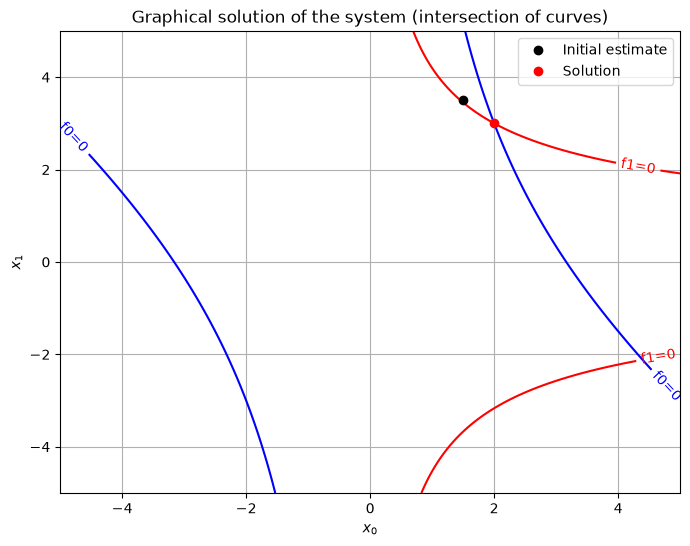

In [54]:
import matplotlib.pyplot as plt

# Prepare the grid of points
x0_range = np.linspace(-5, 5, 400)
x1_range = np.linspace(-5, 5, 400)
X0, X1 = np.meshgrid(x0_range, x1_range)

#  Definition of the system functions
F0 = X0**2 + X0*X1 - 10
F1 = X1 + 3*X0*X1**2 - 57

plt.figure(figsize=(8, 6))

# Plot the zero contour lines (where f(x) = 0)
CS0 = plt.contour(X0, X1, F0, levels=[0], colors='blue')
CS1 = plt.contour(X0, X1, F1, levels=[0], colors='red')

# Labels
plt.clabel(CS0, inline=1, fontsize=10, fmt='f0=0')
plt.clabel(CS1, inline=1, fontsize=10, fmt='f1=0')
plt.plot(1.5, 3.5, 'ko', label='Initial estimate')
plt.plot(solution.x[0], solution.x[1], 'ro', label='Solution')
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.title('Graphical solution of the system (intersection of curves)')
plt.grid(True)
plt.legend()
plt.show()

# Additional

Those of you who are enthusiastic about the [Raspberry Pi](https://www.raspberrypi.org/) and use their camera (e.g. [this one without the infrared filter](https://www.raspberrypi.org/products/pi-noir-camera/)) might be interested in the [picamera](http://picamera.readthedocs.org/) library.

### Using ``sympy.solve`` to solve equations

For smaller systems we can also find the solution symbolically. Let's look at the example above:

In [55]:
import sympy as sym
sym.init_printing()
x, y = sym.symbols('x, y')
functions = [x**2 + x*y -10, y + 3*x*y**2 -57]
functions

In [56]:
sol = sym.solve(functions, x, y)
print(f'Number of solutions: {len(sol)}')
print(f'First solution: {sol[0]}')

Number of solutions: 4
First solution: (2, 3)


---

# Exercise questions

---

**Example 1:** The pressure distribution along the wing of a model airplane is approximated by a line:

<img src="fig/vaje/krilo.png" style="width:550px;">

The internal bending moment for the example shown is defined as:

$$ M(x) = -20x^3 + 24x^2 - 4.2x + 0.2 $$

We are interested in the distance from the airplane fuselage $x$ at which the wing is maximally and minimally loaded in bending.

Let's first find the true solutions using `Sympy` (**Note:** this is not numerical root finding!).

------------

## Numerical root finding (finding zeros)

### Bisection method

**Question 2:** Using the bisection method, determine the zeros of the bending moment $M(x)$ on the interval $[0, l]$. Compare the results with those obtained symbolically and comment on the result. The wing length is $l=1 m$.

$$ M(x) = -20x^3 + 24x^2 - 4.2x + 0.2 $$

**Question 3:** Find the extrema of the function $M(x)$ on the interval $[0 ,l]$.

Comment on the suitability of the bisection method for finding zeros of $f(x)$ in our case. You can check the results using the `Sympy` library.

**Question 4:** The free vibration of a mass-spring system is described by the equation:

$$x(t) = \cos(\pi t)$$

Using the bisection method, find all values of time $t$ on the interval $t \in [0, 20] \, s$ at which the oscillator is in the equilibrium position.

**Question 5:** Solve Problem 3 also using Ridder's method from the ``scipy`` package. Compare the speed of Ridder's method with the bisection method from ``scipy``.

-----------

### Secant method

**Question 6:** Using the secant method, determine all zeros of $M(x)$ on the interval $[0, l]$ (you can use a graphical plot to help).

$$ M(x) = -20x^3 + 24x^2 - 4.2x + 0.2 $$

**Question 7:** You want to compute the natural frequencies of the beam in the figure in the bending direction.

<img src="fig/vaje/konzola_in_podpora.png" style="width:500px;">

In the literature you have read that:

$$ c^2 = EI\, /\, \rho A, \qquad \beta^4 = \omega_0^2 \, / \, c^2$$

and to determine the natural frequencies one must find the intersections of the curves:

$\tanh(\beta l) = \tan(\beta l)$.

Using the bisection and secant methods from the `scipy` module, determine the values of $\beta l$ in the domain $\beta l \in [0, 11]$ that solve the equation above. Use the given values of the initial estimates and intervals.

In [63]:
# Data
intervals = [[3, 4.5], [6, 7.5], [10, 10.5]]
initial_guesses = [2, 6, 10]

----------

### Newton-Raphson method

**Question 8:** Find all three zeros of the function from the previous problem using the Newton-Raphson method.

Determine the first-derivative function using the ``Sympy`` tools; use the function ``sym.lambdify(x, f, 'numpy')`` to help. Use the given values of the initial estimates.

$$ \tanh(\beta l) = \tan(\beta l)$$

In [65]:
# Data
x = sym.symbols('x')
f_sym = sym.tanh(x) - sym.tan(x)
initial_guesses = [2, 6, 10]

----

## Systems of nonlinear equations

**Question 9:** Using ``scipy.optimize.root``, find the solution of the system of nonlinear equations:

$$\sin(x) + y + 2 = 0$$

$$2^x + 3y = 0$$

For the values of the initial estimates choose: $x_0 = 2, \quad y_0 = 0$